- &#9989; global histogram shapes features for all patients;
- &#9989; vizual flatness/elongation shape features;

In [1]:
import os
import pandas as pd
import numpy as np
import glob
import seaborn as sns
import matplotlib.pyplot as plt

In [19]:
# FOR ONE PATIENT
df = pd.read_csv(r"D:\DATA_Myelomy\Myel_001\BMD_radiomics_individual_lesion_features.csv")
df = df.filter(like="shape")  # dataframe with just shape features

shape_features_stats = {}
for col in df.columns:
    x = df[col]

    shape_features_stats[f"{col}_mean"]   = x.mean()
    shape_features_stats[f"{col}_median"] = x.median()
    shape_features_stats[f"{col}_std"]    = x.std()
    shape_features_stats[f"{col}_var"]    = x.var()
    shape_features_stats[f"{col}_cv"]     = x.std() / x.mean()     # coefficient of variation
    shape_features_stats[f"{col}_range"]  = x.max() - x.min()
    shape_features_stats[f"{col}_min"]    = x.min()
    shape_features_stats[f"{col}_max"]    = x.max()

df_shape_features_stats = pd.DataFrame([shape_features_stats])
df_shape_features_stats

,original_shape_Elongation_mean,original_shape_Elongation_median,original_shape_Elongation_std,original_shape_Elongation_var,original_shape_Elongation_cv,original_shape_Elongation_range,original_shape_Elongation_min,original_shape_Elongation_max,original_shape_Flatness_mean,original_shape_Flatness_median,...,original_shape_SurfaceVolumeRatio_min,original_shape_SurfaceVolumeRatio_max,original_shape_VoxelVolume_mean,original_shape_VoxelVolume_median,original_shape_VoxelVolume_std,original_shape_VoxelVolume_var,original_shape_VoxelVolume_cv,original_shape_VoxelVolume_range,original_shape_VoxelVolume_min,original_shape_VoxelVolume_max
0,0.689997,0.760516,0.18199,0.03312,0.263755,0.618176,0.36476,0.982936,0.559757,0.612309,...,1.054741,2.324836,90.066468,67.007816,72.048213,5190.944967,0.799945,418.655669,21.763222,440.418892


# New features from shape features values (min, max, mean, ...)

In [2]:
# FOR ALL PATIENTS
main_folder_path = r"D:\DATA_Myelomy"

all_patients = []
for folder_name in os.listdir(main_folder_path):
    patient_folder_path = os.path.join(main_folder_path, folder_name)

    csv_files = glob.glob(os.path.join(patient_folder_path, "*individual_lesion_features*.csv"))
    csv_path = csv_files[0]  # choose first one (does not matter, shape features are same for every image)

    df = pd.read_csv(csv_path).filter(like="shape")

    shape_features_stats = {"patient_id": folder_name}
    for col in df.columns:
        x = df[col]

        shape_features_stats[f"{col}_mean"]   = x.mean()
        shape_features_stats[f"{col}_median"] = x.median()
        shape_features_stats[f"{col}_std"]    = x.std()
        shape_features_stats[f"{col}_var"]    = x.var()
        shape_features_stats[f"{col}_cv"]     = x.std() / x.mean()     # coefficient of variation
        shape_features_stats[f"{col}_range"]  = x.max() - x.min()
        shape_features_stats[f"{col}_min"]    = x.min()
        shape_features_stats[f"{col}_max"]    = x.max()

    all_patients.append(shape_features_stats)
df_final = pd.DataFrame(all_patients)
df_final

,patient_id,original_shape_Elongation_mean,original_shape_Elongation_median,original_shape_Elongation_std,original_shape_Elongation_var,original_shape_Elongation_cv,original_shape_Elongation_range,original_shape_Elongation_min,original_shape_Elongation_max,original_shape_Flatness_mean,...,original_shape_SurfaceVolumeRatio_min,original_shape_SurfaceVolumeRatio_max,original_shape_VoxelVolume_mean,original_shape_VoxelVolume_median,original_shape_VoxelVolume_std,original_shape_VoxelVolume_var,original_shape_VoxelVolume_cv,original_shape_VoxelVolume_range,original_shape_VoxelVolume_min,original_shape_VoxelVolume_max
0,Myel_001,0.689997,0.760516,0.181990,0.033120,0.263755,0.618176,0.364760,0.982936,0.559757,...,1.054741,2.324836,90.066468,67.007816,72.048213,5.190945e+03,0.799945,418.655669,21.763222,440.418892
1,Myel_002,0.648647,0.653383,0.169330,0.028673,0.261051,0.515505,0.369943,0.885448,0.454540,...,0.841262,1.746274,366.622703,239.994455,340.455556,1.159100e+05,0.928626,1220.019545,45.249551,1265.269096
2,Myel_003,0.711343,0.771383,0.192809,0.037175,0.271050,0.554634,0.333845,0.888479,0.576488,...,1.120211,1.623717,143.621552,95.604581,137.102243,1.879703e+04,0.954608,415.049827,52.095909,467.145736
3,Myel_004,0.695205,0.713297,0.129638,0.016806,0.186475,0.631247,0.343554,0.974801,0.508115,...,0.633748,4.476636,552.265578,175.129278,1397.165564,1.952072e+06,2.529880,9692.203662,5.150861,9697.354523
4,Myel_005,0.696425,0.696445,0.104387,0.010897,0.149890,0.327024,0.546637,0.873662,0.535343,...,0.784054,1.734693,283.266818,175.981890,310.137679,9.618538e+04,1.094861,980.099729,45.682614,1025.782343
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,Myel_077,0.647038,0.678280,0.143430,0.020572,0.221672,0.616463,0.284103,0.900566,0.441154,...,0.644811,5.488186,306.286208,103.305095,542.142336,2.939183e+05,1.770051,3040.775446,4.578619,3045.354065
68,Myel_078,0.646723,0.677827,0.173979,0.030269,0.269017,0.710326,0.227829,0.938156,0.435600,...,0.797936,5.919622,822.970178,109.329732,1738.383593,3.021978e+06,2.112329,8154.509768,5.724070,8160.233838
69,Myel_079,0.702984,0.696841,0.133507,0.017824,0.189914,0.445429,0.487462,0.932891,0.500648,...,0.727774,6.511439,171.004716,64.521916,238.960278,5.710201e+04,1.397390,993.231069,4.064373,997.295442
70,Myel_080,0.644901,0.611859,0.157034,0.024660,0.243501,0.651276,0.348724,1.000000,0.456768,...,0.413366,3.592244,1389.968483,254.106927,2493.733438,6.218706e+06,1.794094,10522.544966,4.578503,10527.123470


In [37]:
# KRUSKAL-WALLIS TEST BETWEEN STAGE GROUPS AND SHAPE STATISTIC FEATURES
pd.set_option('future.no_silent_downcasting', True)
clinical_df = pd.read_csv(r"D:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
clinical_df['Stage'] = clinical_df['ISS classification'].replace({'Stage 1': 1, 'Stage 2': 2, 'Stage 3': 3})

numeric_features = df_final.select_dtypes(include=['number']).columns
data = pd.merge(df_final, clinical_df[['Patient ID', 'Stage']], left_on='patient_id', right_on='Patient ID', how='inner')

results = []
for feature in numeric_features:

    # data = pd.concat([df_final[feature], clinical_df['Stage']], axis=1).dropna()
    stage1 = data[data['Stage'] == 1][feature].dropna()
    stage2 = data[data['Stage'] == 2][feature].dropna()
    stage3 = data[data['Stage'] == 3][feature].dropna()

    from scipy.stats import kruskal
    stat, p_value = kruskal(stage1, stage2, stage3)

    results.append({
        "Feature": feature,
        "H_all": stat,
        "p_value": p_value,
    })
results_df = pd.DataFrame(results).sort_values(by='p_value')
results_df.head(10)

,Feature,H_all,p_value
8,original_shape_Flatness_mean,14.265137,0.000799
9,original_shape_Flatness_median,13.100096,0.001430
1,original_shape_Elongation_median,11.588060,0.003046
0,original_shape_Elongation_mean,11.188244,0.003720
4,original_shape_Elongation_cv,6.592925,0.037014
17,original_shape_LeastAxisLength_median,5.875030,0.052997
65,original_shape_MeshVolume_median,5.757224,0.056213
105,original_shape_VoxelVolume_median,5.433698,0.066083
96,original_shape_SurfaceVolumeRatio_mean,5.263192,0.071964
3,original_shape_Elongation_var,4.900185,0.086286


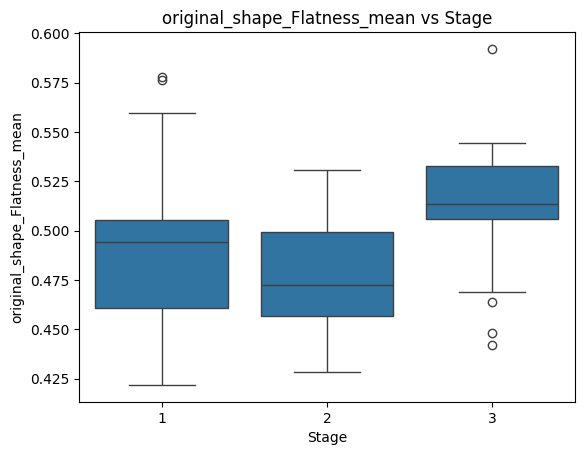

In [44]:
img_feature = "original_shape_Flatness_mean"

sns.boxplot(x='Stage', y=img_feature, data=data)
plt.xlabel('Stage')
plt.ylabel(img_feature)
plt.title(f'{img_feature} vs Stage', fontsize=12)
plt.show()

In [3]:
# SPEARMAN TEST BETWEEN B2-MICROGLOBULIN AND SHAPE STATISTIC FEATURES
pd.set_option('future.no_silent_downcasting', True)
clinical_df = pd.read_csv(r"D:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")

numeric_features = df_final.select_dtypes(include=['number']).columns
data = pd.merge(df_final, clinical_df[['Patient ID', 'Beta2 microglobulin (mg/l)']], left_on='patient_id', right_on='Patient ID', how='inner')

results = []
for feature in numeric_features:

    from scipy.stats import spearmanr
    valid_idx = data[feature].notna() & data['Beta2 microglobulin (mg/l)'].notna()
    corr, p_value = spearmanr(data[feature][valid_idx], data['Beta2 microglobulin (mg/l)'][valid_idx])

    results.append({
        "Feature": feature,
        "corr": corr,
        "p_value": p_value,
    })
results_df = pd.DataFrame(results).sort_values(by='p_value')
results_df.head(10)

,Feature,corr,p_value
8,original_shape_Flatness_mean,0.280938,0.019371
4,original_shape_Elongation_cv,-0.279258,0.020139
16,original_shape_LeastAxisLength_mean,0.269813,0.024958
2,original_shape_Elongation_std,-0.241478,0.045618
3,original_shape_Elongation_var,-0.241478,0.045618
65,original_shape_MeshVolume_median,0.241350,0.045737
105,original_shape_VoxelVolume_median,0.234554,0.052391
17,original_shape_LeastAxisLength_median,0.224122,0.064124
64,original_shape_MeshVolume_mean,0.221930,0.066842
104,original_shape_VoxelVolume_mean,0.220816,0.068258


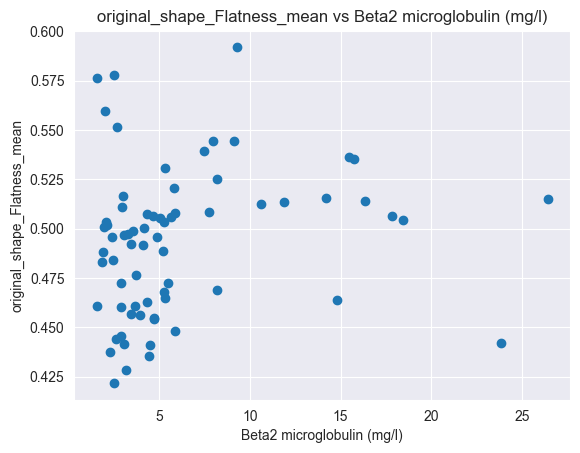

In [4]:
img_feature = "original_shape_Flatness_mean"

plt.scatter(x='Beta2 microglobulin (mg/l)', y=img_feature, data=data)
plt.xlabel('Beta2 microglobulin (mg/l)')
plt.ylabel(img_feature)
plt.title(f'{img_feature} vs Beta2 microglobulin (mg/l)', fontsize=12)
plt.show()

# Shape features distribution

In [7]:
# FOR ONE PATIENT
df = pd.read_csv(r"D:\DATA_Myelomy\Myel_001\BMD_radiomics_individual_lesion_features.csv")
df = df.filter(like="shape")  # dataframe with just shape features
df.head()

,original_shape_Elongation,original_shape_Flatness,original_shape_LeastAxisLength,original_shape_MajorAxisLength,original_shape_Maximum2DDiameterColumn,original_shape_Maximum2DDiameterRow,original_shape_Maximum2DDiameterSlice,original_shape_Maximum3DDiameter,original_shape_MeshVolume,original_shape_MinorAxisLength,original_shape_Sphericity,original_shape_SurfaceArea,original_shape_SurfaceVolumeRatio,original_shape_VoxelVolume
0,0.523404,0.409971,3.302063,8.054378,8.631395,8.903333,5.258950,8.956730,70.921378,4.215692,0.734287,112.841690,1.591081,76.171278
1,0.662979,0.477769,4.519414,9.459419,11.476996,8.830075,9.212872,11.845020,159.549236,6.271396,0.742060,191.708684,1.201564,166.087748
2,0.763670,0.500999,2.918541,5.825440,5.441706,6.583949,6.550980,6.583949,49.182019,4.448714,0.828636,78.341392,1.592887,52.689906
3,0.767038,0.698340,3.916879,5.608843,5.746902,6.850043,5.694289,6.850043,58.297754,4.302194,0.824001,88.238408,1.513582,62.426085
4,0.809943,0.574001,3.564186,6.209370,6.191932,6.443091,6.253051,7.655532,71.136146,5.029234,0.815982,101.749086,1.430343,75.598561


Histograms of shape features

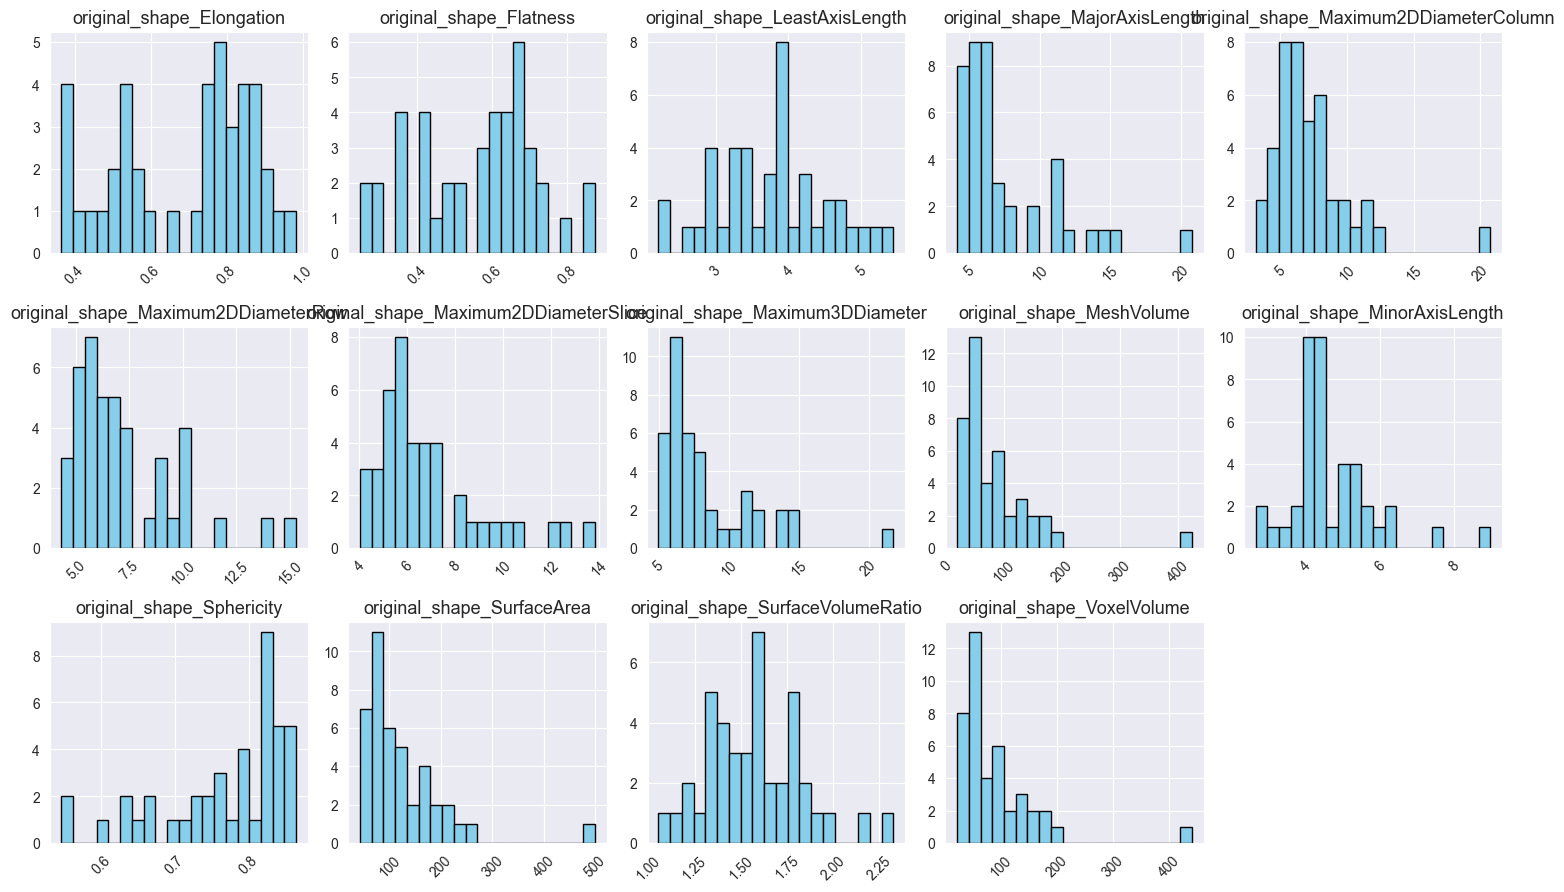

In [10]:
numeric_cols = df.select_dtypes(include=['number']).columns
n_cols = len(numeric_cols)
cols_per_row = 5
rows = (n_cols + cols_per_row - 1) // cols_per_row

plt.figure(figsize=(cols_per_row*3, rows*3))
for i, col in enumerate(numeric_cols):
    plt.subplot(rows, cols_per_row, i+1)
    plt.hist(df[col].dropna(), bins=20, color='skyblue', edgecolor='black')
    plt.title(col, fontsize=13)
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

New features (df) from distribution (histogram) of every shape feature

In [13]:
# Skewness; Kurtosis; Percentile10, 25, 75, 90; IQR (P75-P25); Entropy;

main_folder_path = r"D:\DATA_Myelomy"

all_patients = []
for folder_name in os.listdir(main_folder_path):
    patient_folder_path = os.path.join(main_folder_path, folder_name)

    csv_files = glob.glob(os.path.join(patient_folder_path, "*individual_lesion_features*.csv"))
    csv_path = csv_files[0]  # choose first one (does not matter, shape features are same for every image)

    df = pd.read_csv(csv_path).filter(like="shape")

    shape_features_stats = {"patient_id": folder_name}
    for col in df.columns:
        x = df[col].dropna()

        from scipy.stats import skew, kurtosis
        shape_features_stats[f"{col}_skewness"] = skew(x)
        shape_features_stats[f"{col}_kurtosis"] = kurtosis(x)

        shape_features_stats[f"{col}_percentile10"] = x.quantile(0.10)
        shape_features_stats[f"{col}_percentile25"] = x.quantile(0.25)
        shape_features_stats[f"{col}_percentile75"] = x.quantile(0.75)
        shape_features_stats[f"{col}_percentile90"] = x.quantile(0.90)
        shape_features_stats[f"{col}_IQR"] = x.quantile(0.75) - x.quantile(0.25)  # InterQuartileRange (P75-P25)

        hist, _ = np.histogram(x, bins=20)
        hist = hist / hist.sum()
        hist = hist[hist > 0]

        from scipy.stats import entropy
        shape_features_stats[f"{col}_entropy"] = entropy(hist)

    all_patients.append(shape_features_stats)
df_final = pd.DataFrame(all_patients)
df_final

,patient_id,original_shape_Elongation_skewness,original_shape_Elongation_kurtosis,original_shape_Elongation_percentile10,original_shape_Elongation_percentile25,original_shape_Elongation_percentile75,original_shape_Elongation_percentile90,original_shape_Elongation_IQR,original_shape_Elongation_entropy,original_shape_Flatness_skewness,...,original_shape_SurfaceVolumeRatio_IQR,original_shape_SurfaceVolumeRatio_entropy,original_shape_VoxelVolume_skewness,original_shape_VoxelVolume_kurtosis,original_shape_VoxelVolume_percentile10,original_shape_VoxelVolume_percentile25,original_shape_VoxelVolume_percentile75,original_shape_VoxelVolume_percentile90,original_shape_VoxelVolume_IQR,original_shape_VoxelVolume_entropy
0,Myel_001,-0.404103,-1.206112,0.408275,0.523553,0.835757,0.874718,0.312204,2.708436,-0.278164,...,0.356896,2.609151,2.922179,11.360055,36.195675,49.396787,111.393335,165.171402,61.996547,1.982186
1,Myel_002,-0.302711,-1.088035,0.386232,0.517866,0.757972,0.860897,0.240106,2.504575,0.498056,...,0.346550,2.598143,1.198871,0.289270,85.916869,128.016135,538.125992,902.699907,410.109856,2.301705
2,Myel_003,-0.892735,-0.282743,0.519627,0.599656,0.852615,0.885824,0.252958,1.732868,-0.587916,...,0.308006,2.079442,1.899451,2.132437,58.507714,72.848401,132.672824,269.982756,59.824423,1.732868
3,Myel_004,-0.508973,0.055708,0.508324,0.634663,0.775036,0.840587,0.140372,2.599087,-0.733094,...,0.505232,2.033502,5.528858,32.660202,58.319194,79.266029,412.927366,892.815926,333.661337,0.810010
4,Myel_005,0.142181,-1.042661,0.563766,0.625064,0.766614,0.819095,0.141551,2.253858,0.198178,...,0.641415,2.138333,1.499510,0.965286,58.504894,77.738313,328.992692,729.779766,251.254380,1.907284
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,Myel_077,-0.600689,-0.308193,0.425119,0.563290,0.749318,0.813435,0.186029,2.750925,-0.101079,...,0.534999,1.992297,3.629683,14.027828,40.005685,60.666704,343.396437,649.648825,282.729733,1.287676
68,Myel_078,-0.270684,-0.817304,0.412029,0.504652,0.767897,0.876026,0.263244,2.776891,-0.329122,...,0.788952,2.151550,2.939774,8.234652,18.545986,40.068488,517.026600,2580.696847,476.958112,1.112264
69,Myel_079,0.089847,-1.135792,0.526529,0.588072,0.806714,0.888167,0.218641,2.763015,0.534840,...,0.508067,1.712807,2.163559,3.968904,23.065315,49.788565,148.349602,521.967059,98.561037,1.741921
70,Myel_080,0.254361,-0.870581,0.450690,0.544175,0.794867,0.850074,0.250692,2.713713,0.289201,...,0.676521,2.477443,2.211441,3.921123,42.351155,90.139282,1073.945156,5305.912889,983.805874,1.348498


Kruskal-Wallis test

In [14]:
# KRUSKAL-WALLIS TEST BETWEEN STAGE GROUPS AND SHAPE STATISTIC FEATURES
pd.set_option('future.no_silent_downcasting', True)
clinical_df = pd.read_csv(r"D:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
clinical_df['Stage'] = clinical_df['ISS classification'].replace({'Stage 1': 1, 'Stage 2': 2, 'Stage 3': 3})

numeric_features = df_final.select_dtypes(include=['number']).columns
data = pd.merge(df_final, clinical_df[['Patient ID', 'Stage']], left_on='patient_id', right_on='Patient ID', how='inner')

results = []
for feature in numeric_features:

    stage1 = data[data['Stage'] == 1][feature].dropna()
    stage2 = data[data['Stage'] == 2][feature].dropna()
    stage3 = data[data['Stage'] == 3][feature].dropna()

    from scipy.stats import kruskal
    stat, p_value = kruskal(stage1, stage2, stage3)

    results.append({
        "Feature": feature,
        "H_all": stat,
        "p_value": p_value,
    })
results_df = pd.DataFrame(results).sort_values(by='p_value')
results_df.head(10)

,Feature,H_all,p_value
12,original_shape_Flatness_percentile75,13.662323,0.001080
3,original_shape_Elongation_percentile25,10.925294,0.004242
19,original_shape_LeastAxisLength_percentile25,9.511207,0.008603
11,original_shape_Flatness_percentile25,9.249902,0.009804
79,original_shape_MinorAxisLength_entropy,9.120021,0.010462
68,original_shape_MeshVolume_percentile75,8.309667,0.015688
108,original_shape_VoxelVolume_percentile75,8.309667,0.015688
50,original_shape_Maximum2DDiameterSlice_percenti...,8.271049,0.015994
39,original_shape_Maximum2DDiameterColumn_entropy,8.242640,0.016223
62,original_shape_Maximum3DDiameter_IQR,8.127204,0.017187


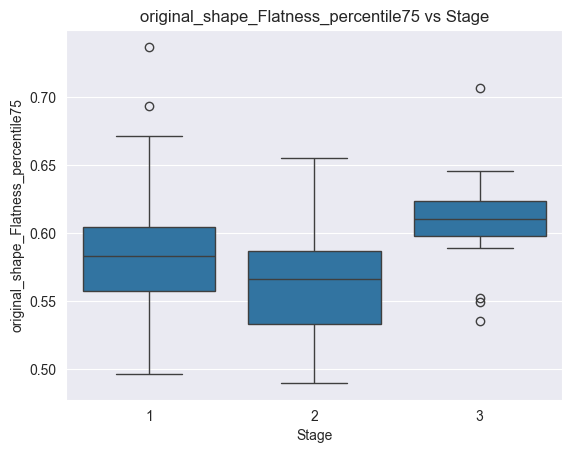

In [15]:
img_feature = "original_shape_Flatness_percentile75"

sns.boxplot(x='Stage', y=img_feature, data=data)
plt.xlabel('Stage')
plt.ylabel(img_feature)
plt.title(f'{img_feature} vs Stage', fontsize=12)
plt.show()

Spearman's test

In [16]:
# SPEARMAN TEST BETWEEN B2-MICROGLOBULIN AND SHAPE STATISTIC FEATURES
pd.set_option('future.no_silent_downcasting', True)
clinical_df = pd.read_csv(r"D:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")

numeric_features = df_final.select_dtypes(include=['number']).columns
data = pd.merge(df_final, clinical_df[['Patient ID', 'Beta2 microglobulin (mg/l)']], left_on='patient_id', right_on='Patient ID', how='inner')

results = []
for feature in numeric_features:

    from scipy.stats import spearmanr
    valid_idx = data[feature].notna() & data['Beta2 microglobulin (mg/l)'].notna()
    corr, p_value = spearmanr(data[feature][valid_idx], data['Beta2 microglobulin (mg/l)'][valid_idx])

    results.append({
        "Feature": feature,
        "corr": corr,
        "p_value": p_value,
    })
results_df = pd.DataFrame(results).sort_values(by='p_value')
results_df.head(10)

,Feature,corr,p_value
21,original_shape_LeastAxisLength_percentile90,0.301144,0.011922
20,original_shape_LeastAxisLength_percentile75,0.276517,0.021448
12,original_shape_Flatness_percentile75,0.261281,0.030118
2,original_shape_Elongation_percentile10,0.255234,0.034294
19,original_shape_LeastAxisLength_percentile25,0.250393,0.037977
109,original_shape_VoxelVolume_percentile90,0.247415,0.040401
69,original_shape_MeshVolume_percentile90,0.246173,0.041450
98,original_shape_SurfaceVolumeRatio_percentile10,-0.241642,0.045467
92,original_shape_SurfaceArea_percentile75,0.226607,0.061153
94,original_shape_SurfaceArea_IQR,0.225200,0.062821


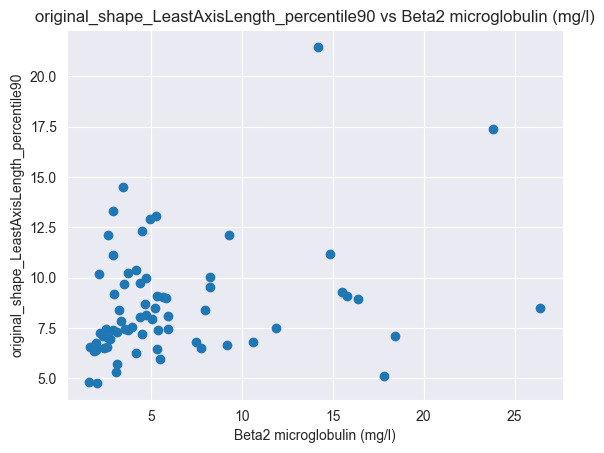

In [17]:
img_feature = "original_shape_LeastAxisLength_percentile90"

plt.scatter(x='Beta2 microglobulin (mg/l)', y=img_feature, data=data)
plt.xlabel('Beta2 microglobulin (mg/l)')
plt.ylabel(img_feature)
plt.title(f'{img_feature} vs Beta2 microglobulin (mg/l)', fontsize=12)
plt.show()

# Flatness & Elongation

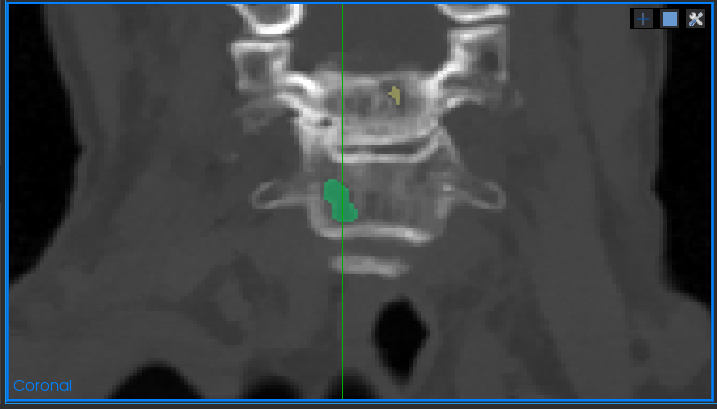 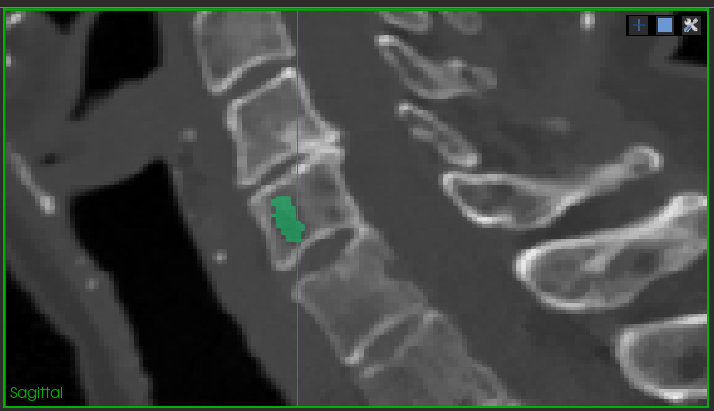
Elongation = 0.96

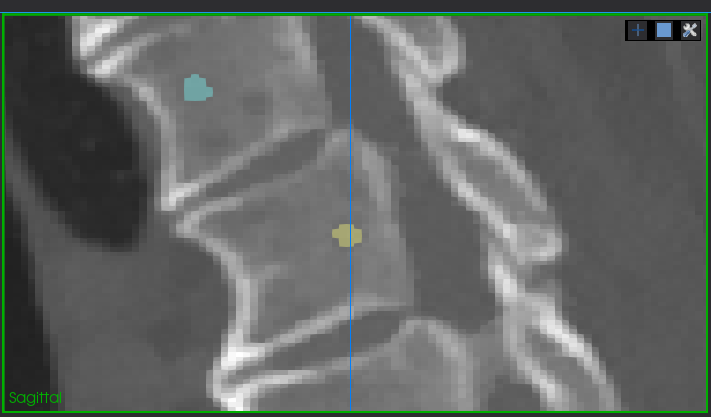 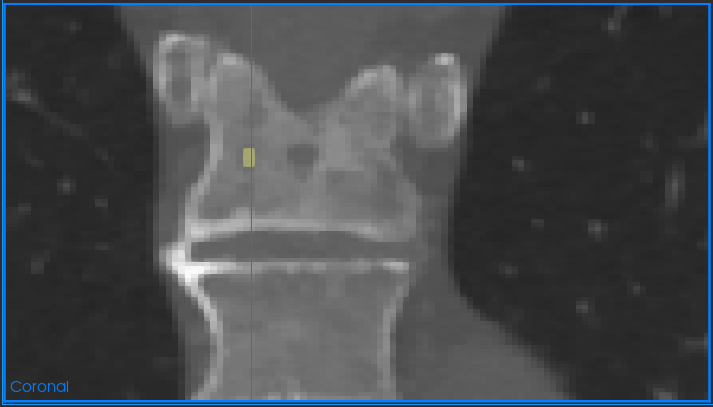
Elongation = 0.55

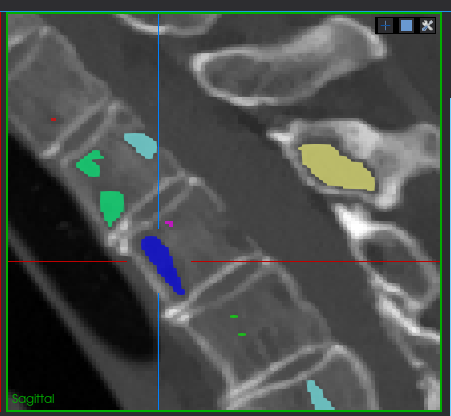
Elongation = 0.37  Flatness = 0.24

Elongation -> Example
- 1.0 – 0.9	takmer guľa
- 0.9 – 0.7	mierne natiahnutá
- 0.7 – 0.5	pretiahnutá
- 0.5 – 0.0	veľmi natiahnutá

Flatness -> Example
- 1.0 - 0.9 guľa
- 0.9 - 0.6 mierne sploštený ovál
- 0.6 - 0.4 plochý disk
- 0.4 - 0.0 veľmi plochá placka

In [42]:
df1 = pd.read_csv(r"E:\DATA_Myelomy\Myel_001\BMD_radiomics_individual_lesion_features.csv").filter(like="shape")
df4 = pd.read_csv(r"E:\DATA_Myelomy\Myel_004\BMD_radiomics_individual_lesion_features.csv").filter(like="shape")

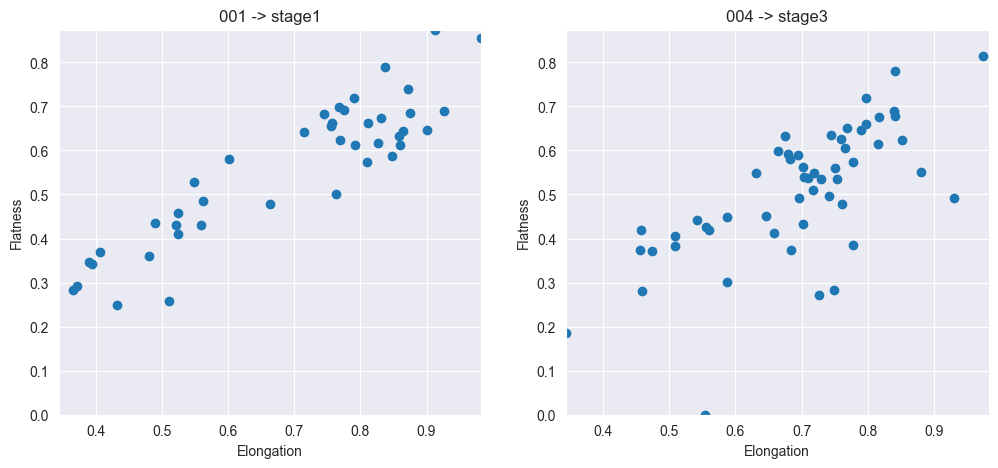

In [43]:
x_min = min(df1["original_shape_Elongation"].min(), df4["original_shape_Elongation"].min())
x_max = max(df1["original_shape_Elongation"].max(), df4["original_shape_Elongation"].max())

y_min = min(df1["original_shape_Flatness"].min(), df4["original_shape_Flatness"].min())
y_max = max(df1["original_shape_Flatness"].max(), df4["original_shape_Flatness"].max())

plt.figure(figsize=(12,5))

plt.subplot(121)
plt.scatter(df1["original_shape_Elongation"], df1["original_shape_Flatness"])
plt.title("001 -> stage1")
plt.xlabel("Elongation")
plt.ylabel("Flatness")
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.subplot(122)
plt.scatter(df4["original_shape_Elongation"], df4["original_shape_Flatness"])
plt.title("004 -> stage3")
plt.xlabel("Elongation")
plt.ylabel("Flatness")
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.show()

# Generalized histograms -> fixed scale

In [25]:
import os, glob
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis, entropy, kruskal

In [27]:
main_folder_path = r"E:\DATA_Myelomy"

all_shape_values = {}
for folder_name in os.listdir(main_folder_path):
    patient_folder = os.path.join(main_folder_path, folder_name)
    csv_files = glob.glob(os.path.join(patient_folder, "*individual_lesion_features*.csv"))
    df = pd.read_csv(csv_files[0]).filter(like="shape")

    for col in df.columns:
        all_shape_values.setdefault(col, []).extend(df[col].dropna().values)

global_ranges = {
    col: (np.min(vals), np.max(vals))
    for col, vals in all_shape_values.items()
}

In [28]:
N_BINS = 20

global_bins = {
    col: np.linspace(vmin, vmax, N_BINS + 1)
    for col, (vmin, vmax) in global_ranges.items()
}

In [29]:
all_patients = []
for folder_name in os.listdir(main_folder_path):
    patient_folder = os.path.join(main_folder_path, folder_name)
    csv_files = glob.glob(os.path.join(patient_folder, "*individual_lesion_features*.csv"))
    df = pd.read_csv(csv_files[0]).filter(like="shape")

    patient_features = {"patient_id": folder_name}
    for col in df.columns:
        x = df[col].dropna().values
        if len(x) < 3:
            continue

        # ===== distribučné príznaky (BEZ histogramu) =====
        patient_features[f"{col}_skewness"] = skew(x)
        patient_features[f"{col}_kurtosis"] = kurtosis(x)

        patient_features[f"{col}_P10"] = np.quantile(x, 0.10)
        patient_features[f"{col}_P25"] = np.quantile(x, 0.25)
        patient_features[f"{col}_P75"] = np.quantile(x, 0.75)
        patient_features[f"{col}_P90"] = np.quantile(x, 0.90)
        patient_features[f"{col}_IQR"] = np.quantile(x, 0.75) - np.quantile(x, 0.25)

        # ===== histogramové príznaky (S FIXNÝMI BINMI) =====
        bins = global_bins[col]

        hist, _ = np.histogram(x, bins=bins)
        hist = hist / hist.sum()
        hist = hist[hist > 0]

        patient_features[f"{col}_hist_entropy"] = entropy(hist)
        patient_features[f"{col}_hist_energy"]  = np.sum(hist ** 2)
        patient_features[f"{col}_hist_uniform"] = np.max(hist)

    all_patients.append(patient_features)

df_final = pd.DataFrame(all_patients)

In [31]:
clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv",encoding="cp1252")
clinical_df['Stage'] = clinical_df['ISS classification'].replace({
    'Stage 1': 1,
    'Stage 2': 2,
    'Stage 3': 3
})

data = pd.merge(
    df_final,
    clinical_df[['Patient ID', 'Stage']],
    left_on='patient_id',
    right_on='Patient ID',
    how='inner'
)

numeric_features = df_final.select_dtypes(include='number').columns

results = []
for feature in numeric_features:
    stage1 = data.loc[data['Stage'] == 1, feature].dropna()
    stage2 = data.loc[data['Stage'] == 2, feature].dropna()
    stage3 = data.loc[data['Stage'] == 3, feature].dropna()

    H, p = kruskal(stage1, stage2, stage3)
    results.append({
        "Feature": feature,
        "H_statistic": H,
        "p_value": p
    })

results_df = pd.DataFrame(results).sort_values("p_value")
results_df.head(10)

,Feature,H_statistic,p_value
14,original_shape_Flatness_P75,13.662323,0.001080
3,original_shape_Elongation_P25,10.925294,0.004242
23,original_shape_LeastAxisLength_P25,9.511207,0.008603
13,original_shape_Flatness_P25,9.249902,0.009804
84,original_shape_MeshVolume_P75,8.309667,0.015688
134,original_shape_VoxelVolume_P75,8.309667,0.015688
62,original_shape_Maximum2DDiameterSlice_P10,8.271049,0.015994
76,original_shape_Maximum3DDiameter_IQR,8.127204,0.017187
56,original_shape_Maximum2DDiameterRow_IQR,8.006453,0.018257
39,original_shape_MajorAxisLength_hist_uniform,7.657523,0.021737
